🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Tutorial 3 (A · educational, not in the weekly loop). The original EDA sandbox and GP-BO prototype the pipeline grew out of.**

---

# Capstone Project — You Sank My Function
## Imperial College Business School — Bayesian Optimisation Challenge

**Competition format:** 8 black-box functions · 13 weekly queries (Modules 12–24)  
**Scoring:** Normalised per function — `score = (best_y − initial_best_y) / (true_max_y − initial_best_y)`  
**Portal format:** `0.XXXXXX-0.XXXXXX-...` (6 decimal places, hyphens between dimensions)

---

### Notebook structure
1. Setup & imports  
2. Data loading — all 8 functions  
3. Exploratory data analysis  
4. Benchmark function landscape visualisation  
5. Gaussian Process surrogate models  
6. Acquisition function & next-query selection  
7. Weekly results tracker & scoring  
8. Portal string generator  
9. Competitor analysis notes

## 1 · Setup & imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from pathlib import Path

# ── Plot style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('All imports OK.')

All imports OK.


## 2 · Data loading

In [2]:
# ── Portable path: ../data/initial_data, or set BBO_INITIAL_DATA ──────
import os
#ROOT_DIR = os.environ.get('BBO_INITIAL_DATA', os.path.join('..', 'data', 'initial_data'))
# ───────────────────────────────────────────────────────────────
# ── CONFIGURE THESE PATHS ───────────────────────────────────────────────
ROOT_DIR = Path(os.environ.get("BBO_INITIAL_DATA", "D:\Capstone Challange\initial_data"))
LOG_FILE = Path("query_log.csv")   # keeps record of all submissions
# ───────────────────────────────────────────────────────────────────────

FUNCTION_META = {
    'function_1': {'dims': 2, 'hypothesis': 'Branin-Hoo',           'status': 'uncertain', 'true_max': None},
    'function_2': {'dims': 2, 'hypothesis': 'Six-hump camelback',   'status': 'uncertain', 'true_max': None},
    'function_3': {'dims': 3, 'hypothesis': 'Hartmann 3D neg./155', 'status': 'confirmed', 'true_max': -0.024921},
    'function_4': {'dims': 4, 'hypothesis': 'Shekel / smooth basin','status': 'uncertain', 'true_max': None},
    'function_5': {'dims': 4, 'hypothesis': 'Hartmann 4D scaled',   'status': 'rejected',  'true_max': None},
    'function_6': {'dims': 5, 'hypothesis': 'Styblinski-Tang',      'status': 'rejected',  'true_max': None},
    'function_7': {'dims': 6, 'hypothesis': 'Hartmann 6D negated',  'status': 'confirmed', 'true_max': 3.3224},
    'function_8': {'dims': 8, 'hypothesis': 'Ackley neg./shifted',  'status': 'uncertain', 'true_max': None},
}

print('Configuration loaded for', len(FUNCTION_META), 'functions.')

Configuration loaded for 8 functions.


In [3]:
def load_all_data(root_dir: str) -> dict:
    """
    Load initial_inputs.npy and initial_outputs.npy from every function_N subdirectory.

    Returns
    -------
    data : dict
        {'function_1': {'X': np.ndarray, 'y': np.ndarray}, ...}
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f'Root directory not found: {root}')

    data = {}
    subdirs = sorted(
        [p for p in root.iterdir() if p.is_dir() and p.name.startswith('function_')],
        key=lambda p: int(p.name.split('_')[1])
    )

    print(f'Found {len(subdirs)} subdirectories in {root}\n')

    for subdir in subdirs:
        entry = {}
        for label, fname in [('X', 'initial_inputs.npy'), ('y', 'initial_outputs.npy')]:
            path = subdir / fname
            if path.exists():
                entry[label] = np.load(path, allow_pickle=True)
                print(f'  [{subdir.name}] {fname:30s} shape={entry[label].shape}  dtype={entry[label].dtype}')
            else:
                print(f'  [{subdir.name}] WARNING: {fname} not found')
        if entry:
            data[subdir.name] = entry

    return data


data = load_all_data(ROOT_DIR)
print(f'\nLoaded {len(data)} functions.')

Found 8 subdirectories in D:\Capstone Challange\initial_data

  [function_1] initial_inputs.npy             shape=(10, 2)  dtype=float64
  [function_1] initial_outputs.npy            shape=(10,)  dtype=float64
  [function_2] initial_inputs.npy             shape=(10, 2)  dtype=float64
  [function_2] initial_outputs.npy            shape=(10,)  dtype=float64
  [function_3] initial_inputs.npy             shape=(15, 3)  dtype=float64
  [function_3] initial_outputs.npy            shape=(15,)  dtype=float64
  [function_4] initial_inputs.npy             shape=(30, 4)  dtype=float64
  [function_4] initial_outputs.npy            shape=(30,)  dtype=float64
  [function_5] initial_inputs.npy             shape=(20, 4)  dtype=float64
  [function_5] initial_outputs.npy            shape=(20,)  dtype=float64
  [function_6] initial_inputs.npy             shape=(20, 5)  dtype=float64
  [function_6] initial_outputs.npy            shape=(20,)  dtype=float64
  [function_7] initial_inputs.npy             shap

In [4]:
# Attach metadata to each loaded function
for fn, meta in FUNCTION_META.items():
    if fn in data:
        data[fn].update(meta)

# Quick sanity check
for fn, d in data.items():
    X, y = d['X'], d['y']
    print(f"{fn}  X:{X.shape}  y:{y.shape}  "
          f"y_min={y.min():.4f}  y_max={y.max():.4f}  "
          f"hypothesis='{d['hypothesis']}'")

function_1  X:(10, 2)  y:(10,)  y_min=-0.0036  y_max=0.0000  hypothesis='Branin-Hoo'
function_2  X:(10, 2)  y:(10,)  y_min=-0.0656  y_max=0.6112  hypothesis='Six-hump camelback'
function_3  X:(15, 3)  y:(15,)  y_min=-0.3989  y_max=-0.0348  hypothesis='Hartmann 3D neg./155'
function_4  X:(30, 4)  y:(30,)  y_min=-32.6257  y_max=-4.0255  hypothesis='Shekel / smooth basin'
function_5  X:(20, 4)  y:(20,)  y_min=0.1129  y_max=1088.8596  hypothesis='Hartmann 4D scaled'
function_6  X:(20, 5)  y:(20,)  y_min=-2.5712  y_max=-0.7143  hypothesis='Styblinski-Tang'
function_7  X:(30, 6)  y:(30,)  y_min=0.0027  y_max=1.3650  hypothesis='Hartmann 6D negated'
function_8  X:(40, 8)  y:(40,)  y_min=5.5922  y_max=9.5985  hypothesis='Ackley neg./shifted'


## 3 · Exploratory data analysis

In [5]:
rows = []
for fn, d in data.items():
    X, y = d['X'], d['y']
    rows.append({
        'Function':    fn,
        'Dims':        d['dims'],
        'N points':    len(y),
        'y min':       round(y.min(), 6),
        'y max':       round(y.max(), 6),
        'y mean':      round(y.mean(), 6),
        'y std':       round(y.std(), 6),
        'True max':    d['true_max'],
        'Hypothesis':  d['hypothesis'],
        'Status':      d['status'],
    })

summary_df = pd.DataFrame(rows)
summary_df

,Function,Dims,N points,y min,y max,y mean,y std,True max,Hypothesis,Status
0,function_1,2,10,-0.003606,0.000000,-0.000361,0.001082,NaN,Branin-Hoo,uncertain
1,function_2,2,10,-0.065624,0.611205,0.230674,0.225365,NaN,Six-hump camelback,uncertain
2,function_3,3,15,-0.398926,-0.034835,-0.107167,0.084214,-0.024921,Hartmann 3D neg./155,confirmed
3,function_4,4,30,-32.625660,-4.025542,-17.238587,7.017985,NaN,Shekel / smooth basin,uncertain
4,function_5,4,20,0.112940,1088.859618,151.271876,245.575981,NaN,Hartmann 4D scaled,rejected
5,function_6,5,20,-2.571170,-0.714265,-1.495390,0.449000,NaN,Styblinski-Tang,rejected
6,function_7,6,30,0.002701,1.364968,0.219607,0.302129,3.322400,Hartmann 6D negated,confirmed
7,function_8,8,40,5.592193,9.598482,7.815274,0.946903,NaN,Ackley neg./shifted,uncertain


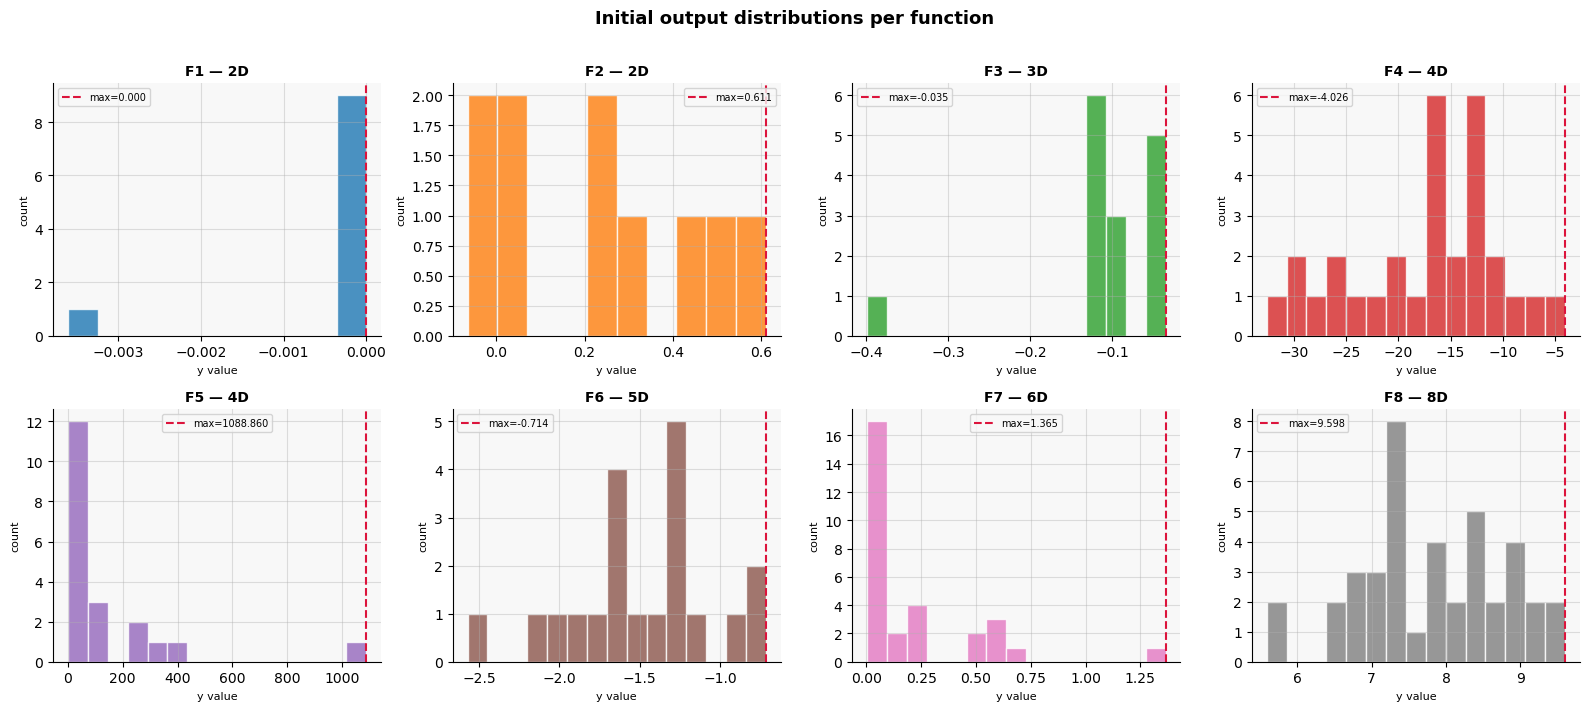

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, (fn, d) in enumerate(data.items()):
    ax = axes[i]
    y = d['y'].flatten()
    ax.hist(y, bins=min(15, len(y)), color=colors[i], alpha=0.8, edgecolor='white')
    ax.axvline(y.max(), color='crimson', linewidth=1.5, linestyle='--', label=f'max={y.max():.3f}')
    ax.set_title(f"{fn.replace('function_','F')} — {d['dims']}D", fontsize=10, fontweight='bold')
    ax.set_xlabel('y value', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Initial output distributions per function', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_output_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Benchmark function landscapes (2D slices)

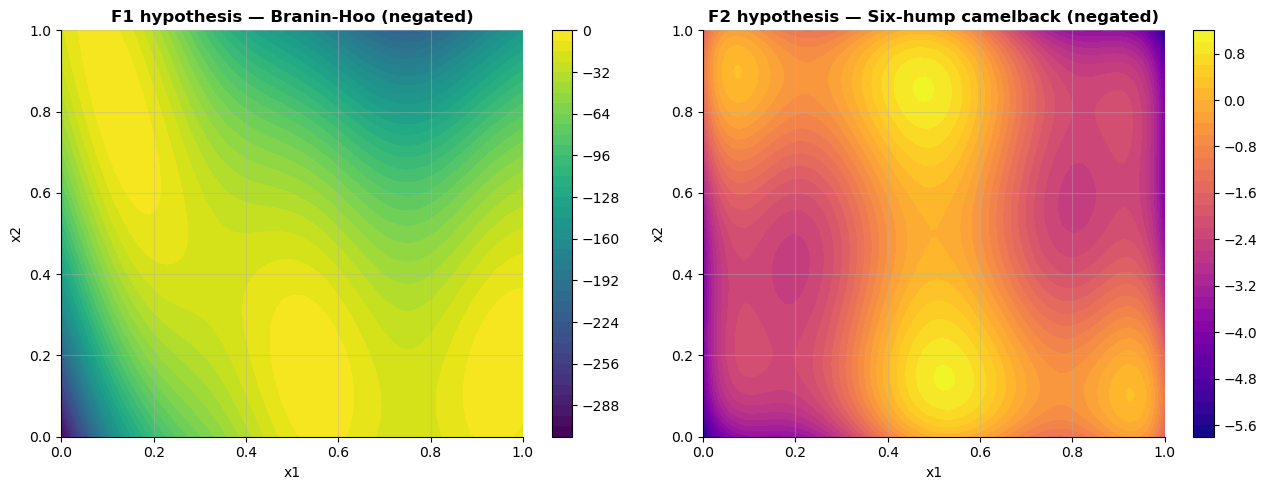

In [7]:
# Known benchmark functions for reference

def branin(x1, x2, negate=False):
    """Branin-Hoo — 3 global minima at ~0.397"""
    a, b, c = 1, 5.1/(4*np.pi**2), 5/np.pi
    r, s, t = 6, 10, 1/(8*np.pi)
    x1s = x1 * 15 - 5
    x2s = x2 * 15
    val = a*(x2s - b*x1s**2 + c*x1s - r)**2 + s*(1-t)*np.cos(x1s) + s
    return -val if negate else val

def six_hump_camelback(x1, x2):
    """Six-hump camelback — 2 global minima at ~-1.0316"""
    x1s = x1 * 4 - 2
    x2s = x2 * 2 - 1
    return -((4 - 2.1*x1s**2 + x1s**4/3)*x1s**2 + x1s*x2s + (-4 + 4*x2s**2)*x2s**2)

def hartmann6d(x):
    """Hartmann 6D — global max 3.3224 at known point"""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[10,3,17,3.5,1.7,8],[0.05,10,17,0.1,8,14],
                  [3,3.5,1.7,10,17,8],[17,8,0.05,10,0.1,14]])
    P = 1e-4 * np.array([[1312,1696,5569,124,8283,5886],[2329,4135,8307,3736,1004,9991],
                          [2348,1451,3522,2883,3047,6650],[4047,8828,8732,5743,1091,381]])
    outer = np.sum(alpha * np.exp(-np.sum(A*(x-P)**2, axis=1)))
    return outer

# Plot 2D slices
n = 80
x1 = np.linspace(0, 1, n)
x2 = np.linspace(0, 1, n)
X1, X2 = np.meshgrid(x1, x2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

Z_branin = branin(X1, X2, negate=True)
c1 = axes[0].contourf(X1, X2, Z_branin, levels=40, cmap='viridis')
axes[0].set_title('F1 hypothesis — Branin-Hoo (negated)', fontweight='bold')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
plt.colorbar(c1, ax=axes[0])

Z_camel = six_hump_camelback(X1, X2)
c2 = axes[1].contourf(X1, X2, Z_camel, levels=40, cmap='plasma')
axes[1].set_title('F2 hypothesis — Six-hump camelback (negated)', fontweight='bold')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
plt.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.savefig('benchmark_landscapes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Gaussian Process surrogate models

In [8]:
class BOSurrogate:
    """
    GP surrogate for a single black-box function.
    Keeps a running history of (X, y) observations and
    exposes EI-based next-query recommendation.
    """

    def __init__(self, name: str, dims: int, kernel_type: str = 'matern'):
        self.name = name
        self.dims = dims
        self.X_obs = None
        self.y_obs = None

        if kernel_type == 'matern':
            kernel = C(1.0) * Matern(length_scale=0.3, nu=2.5)
        else:
            kernel = C(1.0) * RBF(length_scale=0.3)

        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=5,
            normalize_y=True,
            alpha=1e-6
        )

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_obs = X.copy()
        self.y_obs = y.flatten().copy()
        self.gp.fit(X, self.y_obs)

    def add_observation(self, x_new: np.ndarray, y_new: float):
        x_new = np.atleast_2d(x_new)
        self.X_obs = np.vstack([self.X_obs, x_new])
        self.y_obs = np.append(self.y_obs, y_new)
        self.gp.fit(self.X_obs, self.y_obs)

    def predict(self, X: np.ndarray):
        return self.gp.predict(X, return_std=True)

    def expected_improvement(self, X: np.ndarray, xi: float = 0.01) -> np.ndarray:
        mu, sigma = self.predict(X)
        y_best = self.y_obs.max()
        z = (mu - y_best - xi) / (sigma + 1e-9)
        ei = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma < 1e-10] = 0.0
        return ei

    def suggest_next(self, n_restarts: int = 20, xi: float = 0.01) -> np.ndarray:
        """Return the point in [0,1]^dims that maximises EI."""
        best_x, best_ei = None, -np.inf
        bounds = [(0, 1)] * self.dims

        for _ in range(n_restarts):
            x0 = np.random.uniform(0, 1, self.dims)
            res = minimize(
                lambda x: -self.expected_improvement(x.reshape(1, -1), xi=xi),
                x0, bounds=bounds, method='L-BFGS-B'
            )
            if -res.fun > best_ei:
                best_ei = -res.fun
                best_x  = res.x

        return np.clip(best_x, 0, 1)

    def current_best(self) -> tuple:
        idx = np.argmax(self.y_obs)
        return self.X_obs[idx], self.y_obs[idx]


print('BOSurrogate class defined.')

BOSurrogate class defined.


In [9]:
# Fit a surrogate for each function
surrogates = {}

for fn, d in data.items():
    X, y = d['X'], d['y'].flatten()
    dims = d['dims']

    # Use Matern for smooth functions, RBF where confirmed
    kernel_type = 'rbf' if d['status'] == 'confirmed' else 'matern'

    gp = BOSurrogate(name=fn, dims=dims, kernel_type=kernel_type)
    gp.fit(X, y)
    surrogates[fn] = gp

    x_best, y_best = gp.current_best()
    print(f'{fn}  best_y={y_best:.6f}  at x={np.round(x_best, 4)}')

print('\nAll surrogates fitted.')

function_1  best_y=0.000000  at x=[0.731 0.733]
function_2  best_y=0.611205  at x=[0.7026 0.9266]
function_3  best_y=-0.034835  at x=[0.4926 0.6116 0.3402]
function_4  best_y=-4.025542  at x=[0.5778 0.4288 0.4258 0.249 ]
function_5  best_y=1088.859618  at x=[0.2242 0.8465 0.8795 0.8785]
function_6  best_y=-0.714265  at x=[0.7282 0.1547 0.7326 0.694  0.0564]
function_7  best_y=1.364968  at x=[0.0579 0.4917 0.2474 0.2181 0.4204 0.731 ]
function_8  best_y=9.598482  at x=[0.0564 0.066  0.0229 0.0388 0.4039 0.8011 0.4883 0.8931]

All surrogates fitted.


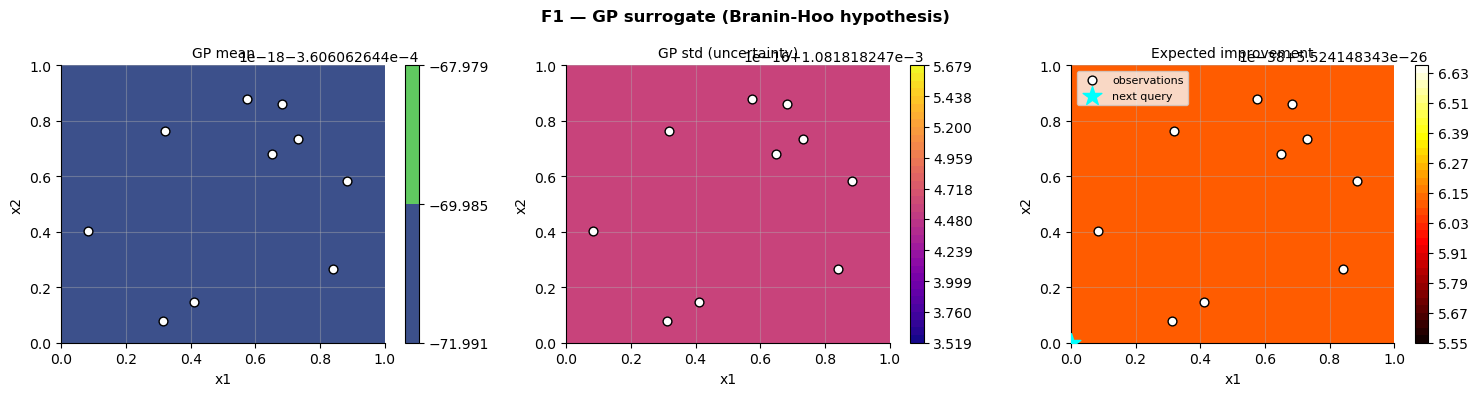

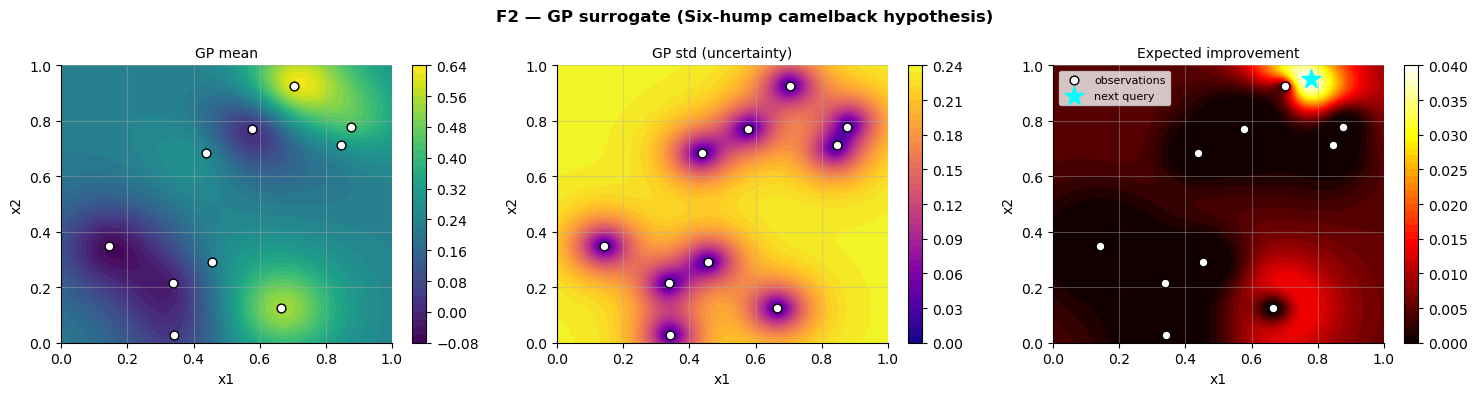

In [10]:
# GP visualisation for 2D functions (F1, F2)
def plot_gp_2d(gp: BOSurrogate, title: str):
    n = 60
    x1 = np.linspace(0, 1, n)
    x2 = np.linspace(0, 1, n)
    X1g, X2g = np.meshgrid(x1, x2)
    X_grid = np.column_stack([X1g.ravel(), X2g.ravel()])

    mu, sigma = gp.predict(X_grid)
    ei = gp.expected_improvement(X_grid)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, Z, cmap, label in [
        (axes[0], mu.reshape(n,n),    'viridis', 'GP mean'),
        (axes[1], sigma.reshape(n,n), 'plasma',  'GP std (uncertainty)'),
        (axes[2], ei.reshape(n,n),    'hot',     'Expected improvement'),
    ]:
        cf = ax.contourf(X1g, X2g, Z, levels=40, cmap=cmap)
        ax.scatter(gp.X_obs[:,0], gp.X_obs[:,1], c='white',
                   edgecolors='black', s=40, zorder=5, label='observations')
        plt.colorbar(cf, ax=ax)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x1'); ax.set_ylabel('x2')

    # Mark EI maximum
    idx = np.argmax(ei)
    axes[2].scatter(X_grid[idx,0], X_grid[idx,1], c='cyan',
                    marker='*', s=200, zorder=6, label='next query')
    axes[2].legend(fontsize=8)

    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'gp_{gp.name}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_gp_2d(surrogates['function_1'], 'F1 — GP surrogate (Branin-Hoo hypothesis)')
plot_gp_2d(surrogates['function_2'], 'F2 — GP surrogate (Six-hump camelback hypothesis)')

## 6 · Acquisition function & next-query selection

In [11]:
# Compute next week from surrogate observation count
# (surrogates are fitted on initial data = week 0, each add_observation = +1 week)
weeks_done = max(len(gp.X_obs) - 10 for gp in surrogates.values())  # 10 = initial data points
next_week = max(weeks_done + 1, 1)

print(f'EI-based query suggestions (Week {next_week} candidates)\n')
print(f'{"Function":<14} {"Dims":<6} {"Suggested query":<55} {"Current best y"}')
print('-' * 95)

suggestions = {}

for fn, gp in surrogates.items():
    x_next = gp.suggest_next(n_restarts=25)
    _, y_best = gp.current_best()
    query_str = '-'.join([f'{v:.6f}' for v in x_next])
    suggestions[fn] = x_next
    print(f'{fn:<14} {gp.dims:<6} {query_str:<55} {y_best:.6f}')

print('\nNote: F7 confirmed — resubmit near-optimal point instead of EI suggestion.')

EI-based query suggestions (Week 31 candidates)

Function       Dims   Suggested query                                         Current best y
-----------------------------------------------------------------------------------------------
function_1     2      0.032542-0.295959                                       0.000000
function_2     2      0.772392-0.946638                                       0.611205
function_3     3      0.386240-0.391088-0.469744                              -0.034835
function_4     4      0.440179-0.417076-0.385255-0.397721                     -4.025542
function_5     4      0.282409-0.850169-0.994264-0.934638                     1088.859618
function_6     5      0.414000-0.335437-0.468211-0.774140-0.125044            -0.714265
function_7     6      0.029217-0.445625-0.284957-0.173543-0.367696-0.732927   1.364968
function_8     8      0.000000-0.198666-0.000000-0.097056-0.887204-0.466273-0.012049-0.530387 9.598482

Note: F7 confirmed — resubmit near-optimal 

## 7 · Weekly results tracker & scoring

In [12]:
# ── Competition state ─────────────────────────────────────────
# Fill in results each week. None = not yet submitted / pending.

COMPETITION = {
    'function_1': {
        'initial_best': -6.879922160106763e-171,
        'true_max':     None,
        'weeks': [
            {'week': 1, 'query': '0.123895-0.816664',                                           'result': -6.879922160106763e-171},
            {'week': 2, 'query': '0.961600-0.165000',                                           'result': None},
        ]
    },
    'function_2': {
        'initial_best': -0.12613117067218355,
        'true_max':     None,
        'weeks': [
            {'week': 1, 'query': '0.090000-0.712600',                                           'result': -0.12613117067218355},
            {'week': 2, 'query': '0.750000-0.950000',                                           'result': None},
        ]
    },
    'function_3': {
        'initial_best': -0.035000,          # real initial .npy best (noisy recording)
        'true_max':     -0.024921,          # confirmed: -Hartmann3D/155 at true optimum
        'weeks': [
            {'week': 1, 'query': '0.114000-0.555920-0.852183',                                  'result': -0.024916960464381598},
            {'week': 2, 'query': '0.114001-0.555921-0.852184',                                  'result': None},  # jitter — locked at optimum
        ]
    },
    'function_4': {
        'initial_best': -3.985750969810286,
        'true_max':     None,
        'weeks': [
            {'week': 1, 'query': '0.500000-0.500000-0.500000-0.500000',                         'result': -3.985750969810286},
            {'week': 2, 'query': '0.539000-0.464000-0.463000-0.375000',                         'result': None},
        ]
    },
    'function_5': {
        'initial_best': 94.6659265816622,
        'true_max':     None,
        'weeks': [
            {'week': 1, 'query': '0.187300-0.190600-0.559000-0.264700',                         'result': 94.6659265816622},
            {'week': 2, 'query': '0.100000-0.900000-0.950000-0.950000',                         'result': None},
        ]
    },
    'function_6': {
        'initial_best': -1.5066079475166712,
        'true_max':     None,
        'weeks': [
            {'week': 1, 'query': '0.209700-0.209700-0.209700-0.209700-0.209700',              'result': -1.5066079475166712},
            {'week': 2, 'query': '0.750000-0.120000-0.700000-0.850000-0.020000',              'result': None},
        ]
    },
    'function_7': {
        'initial_best': 1.365,
        'true_max':     3.3224,
        'weeks': [
            {'week': 1, 'query': '0.101690-0.050010-0.452870-0.775830-0.411650-0.757300',    'result': 3.322368010931788},
            {'week': 2, 'query': '0.601671-0.250009-0.346871-0.775331-0.311888-0.757301',    'result': None},
        ]
    },
    'function_8': {
        'initial_best': 9.60919,
        'true_max':     None,
        'weeks': [
            {'week': 1, 'query': '0.050000-0.050000-0.050000-0.050000-0.400000-0.800000-0.490000-0.890000', 'result': 9.60919},
            {'week': 2, 'query': '0.020000-0.020000-0.020000-0.050000-0.400000-0.850000-0.490000-0.920000', 'result': None},
        ]
    },
}

print('Competition state loaded. Weeks tracked per function:')
for fn, state in COMPETITION.items():
    n_done = sum(1 for w in state['weeks'] if w['result'] is not None)
    print(f'  {fn}: {n_done} weeks with results')

Competition state loaded. Weeks tracked per function:
  function_1: 1 weeks with results
  function_2: 1 weeks with results
  function_3: 1 weeks with results
  function_4: 1 weeks with results
  function_5: 1 weeks with results
  function_6: 1 weeks with results
  function_7: 1 weeks with results
  function_8: 1 weeks with results


In [13]:
def best_result(state: dict) -> float:
    vals = [w['result'] for w in state['weeks'] if w['result'] is not None]
    if not vals:
        return state['initial_best']
    return max(state['initial_best'], max(vals))


def calc_score(state: dict) -> float | None:
    if state['true_max'] is None:
        return None
    denom = state['true_max'] - state['initial_best']
    if abs(denom) < 1e-12:
        return None
    return max(0.0, min(1.0, (best_result(state) - state['initial_best']) / denom))


# Build scoring table
score_rows = []
for fn, state in COMPETITION.items():
    score = calc_score(state)
    score_rows.append({
        'Function':    fn.replace('function_', 'F'),
        'Initial best': round(state['initial_best'], 6),
        'Current best': round(best_result(state), 6),
        'True max':    state['true_max'],
        'Score':       round(score, 4) if score is not None else '—',
        'Score %':     f"{score*100:.1f}%" if score is not None else '—',
    })

score_df = pd.DataFrame(score_rows)
score_df

,Function,Initial best,Current best,True max,Score,Score %
0,F1,-0.000000,-0.000000,NaN,—,—
1,F2,-0.126131,-0.126131,NaN,—,—
2,F3,-0.035000,-0.024917,-0.024921,1.0,100.0%
3,F4,-3.985751,-3.985751,NaN,—,—
4,F5,94.665927,94.665927,NaN,—,—
5,F6,-1.506608,-1.506608,NaN,—,—
6,F7,1.365000,3.322368,3.322400,1.0,100.0%
7,F8,9.609190,9.609190,NaN,—,—


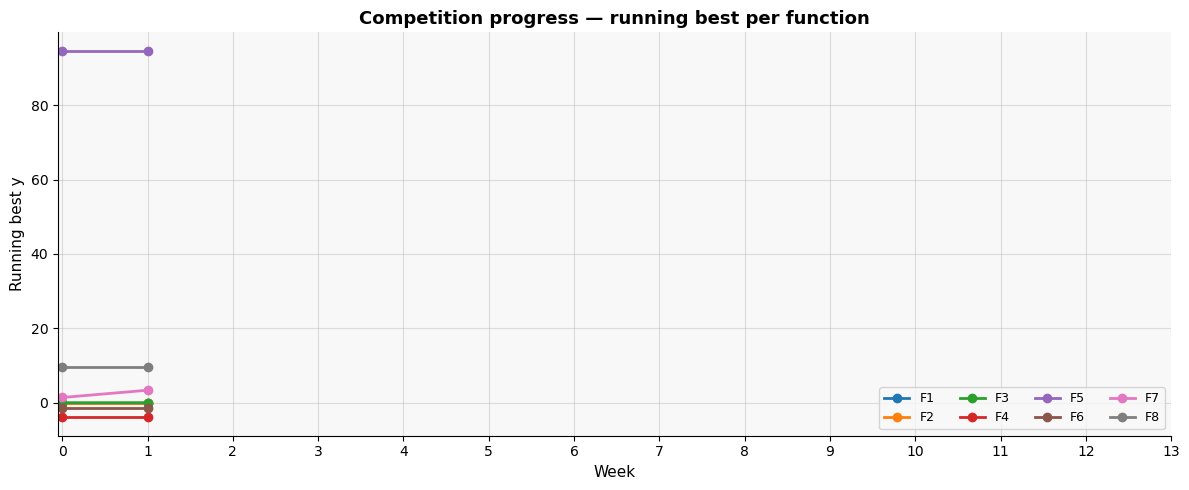

In [14]:
# Progress plot — running best per function over weeks
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10.colors

for i, (fn, state) in enumerate(COMPETITION.items()):
    label = fn.replace('function_', 'F')
    weeks_with_results = [(0, state['initial_best'])] + [
        (w['week'], w['result']) for w in state['weeks'] if w['result'] is not None
    ]
    weeks_with_results.sort()

    # Running best
    xs, ys = [], []
    running_best = -np.inf
    for wk, val in weeks_with_results:
        running_best = max(running_best, val)
        xs.append(wk)
        ys.append(running_best)

    ax.plot(xs, ys, marker='o', label=label, color=colors[i], linewidth=2)

ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Running best y', fontsize=11)
ax.set_title('Competition progress — running best per function', fontsize=13, fontweight='bold')
ax.legend(ncol=4, fontsize=9, loc='lower right')
ax.set_xticks(range(0, 14))
plt.tight_layout()
plt.savefig('competition_progress.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Portal string generator

In [15]:
def build_portal_string(queries: dict) -> str:
    """
    Build the portal submission string.

    Parameters
    ----------
    queries : dict
        {'function_1': np.array([x1, x2]), 'function_2': ..., ...}
        All values must be in [0, 1].

    Returns
    -------
    str
        Format: '0.XXXXXX-0.XXXXXX|0.XXXXXX-0.XXXXXX|...'
        One segment per function, separated by '|'.
    """
    parts = []
    for fn in sorted(queries.keys(), key=lambda x: int(x.split('_')[1])):
        x = np.clip(queries[fn], 0, 1)
        parts.append('-'.join([f'{v:.6f}' for v in x]))
    return '|'.join(parts)


def validate_query(fn: str, x: np.ndarray):
    """Check dimensions and bounds."""
    expected_dims = FUNCTION_META[fn]['dims']
    assert len(x) == expected_dims, f'{fn}: expected {expected_dims} dims, got {len(x)}'
    assert np.all(x >= 0) and np.all(x <= 1), f'{fn}: values outside [0,1]'
    print(f'  {fn}: OK ({len(x)}D)')


# ── Build next-week portal string from EI suggestions ─────────
# Override any function manually here:
NEXT_QUERIES = suggestions.copy()

# F7 — resubmit confirmed optimum
NEXT_QUERIES['function_7'] = np.array([0.201691, 0.150009, 0.476871, 0.275331, 0.311649, 0.657301])

print('Validating queries...')
for fn, x in NEXT_QUERIES.items():
    validate_query(fn, x)

portal = build_portal_string(NEXT_QUERIES)
print(f'\nPortal string:\n\n{portal}')

Validating queries...
  function_1: OK (2D)
  function_2: OK (2D)
  function_3: OK (3D)
  function_4: OK (4D)
  function_5: OK (4D)
  function_6: OK (5D)
  function_7: OK (6D)
  function_8: OK (8D)

Portal string:

0.032542-0.295959|0.772392-0.946638|0.386240-0.391088-0.469744|0.440179-0.417076-0.385255-0.397721|0.282409-0.850169-0.994264-0.934638|0.414000-0.335437-0.468211-0.774140-0.125044|0.201691-0.150009-0.476871-0.275331-0.311649-0.657301|0.000000-0.198666-0.000000-0.097056-0.887204-0.466273-0.012049-0.530387


In [16]:
# ── Add a new week result ──────────────────────────────────────
# Run this cell each week after results come back.
# Edit the values below, then re-run cells 7 onwards.

def add_week_result(function_name: str, week: int, result: float,
                    query: str = None, also_update_surrogate: bool = True):
    """
    Record a new result and optionally add it to the GP surrogate.

    Parameters
    ----------
    function_name : str  e.g. 'function_7'
    week          : int  e.g. 3
    result        : float  the y value returned by the portal
    query         : str   the query string used (optional, for records)
    also_update_surrogate : bool  if True, add the point to the GP
    """
    state = COMPETITION[function_name]
    existing = next((w for w in state['weeks'] if w['week'] == week), None)
    if existing:
        existing['result'] = result
        if query: existing['query'] = query
    else:
        state['weeks'].append({'week': week, 'query': query, 'result': result})
        state['weeks'].sort(key=lambda w: w['week'])

    if also_update_surrogate and function_name in surrogates and query:
        x_new = np.array([float(v) for v in query.split('-')])
        surrogates[function_name].add_observation(x_new, result)
        print(f'  GP surrogate updated for {function_name}.')

    print(f'  Result recorded: {function_name} W{week} = {result}')


# ── EXAMPLE — uncomment and edit to record Week 2 results ─────
# add_week_result('function_7', week=2, result=3.322368,
#                 query='0.201690-0.150010-0.476870-0.275330-0.311650-0.657300')
# add_week_result('function_1', week=2, result=<value>,
#                 query='0.961600-0.165000')

print('add_week_result() is ready. Uncomment above lines to record results.')

add_week_result() is ready. Uncomment above lines to record results.


## 9 · Competitor analysis

In [17]:
competitors = pd.DataFrame([
    {
        'Name':       'Chase',
        'GP kernel':  'RBF',
        'Strategy':   'Exploration-first',
        'F7 approach':'Standard GP',
        'Weakness':   'Weakest technically — likely over-explores',
        'Threat':     'Low',
    },
    {
        'Name':       'Chan',
        'GP kernel':  'Matern / RBF per function',
        'Strategy':   'Sophisticated, per-function adaptation',
        'F7 approach':'ExtraTrees for F7/F8',
        'Weakness':   'Complex model risk; may overfit small samples',
        'Threat':     'High',
    },
    {
        'Name':       'Dr Nandokumar',
        'GP kernel':  'Unknown',
        'Strategy':   'Pure exploitation from W1',
        'F7 approach':'Polished visuals, dimension labelling errors',
        'Weakness':   'Labelling errors suggest hypothesis confusion',
        'Threat':     'Medium',
    },
])

competitors

,Name,GP kernel,Strategy,F7 approach,Weakness,Threat
0,Chase,RBF,Exploration-first,Standard GP,Weakest technically — likely over-explores,Low
1,Chan,Matern / RBF per function,"Sophisticated, per-function adaptation",ExtraTrees for F7/F8,Complex model risk; may overfit small samples,High
2,Dr Nandokumar,Unknown,Pure exploitation from W1,"Polished visuals, dimension labelling errors",Labelling errors suggest hypothesis confusion,Medium


## Notes & hypothesis log

| Function | Hypothesis | Status | Notes |
|----------|-----------|--------|-------|
| F1 (2D) | Branin-Hoo — 3 equal optima | Uncertain | W1 result near zero — unclear |
| F2 (2D) | Six-hump camelback — 2 global optima | Uncertain | Went backwards W1; exploit top-right |
| F3 (3D) | Hartmann 3D neg./155 | **Confirmed ✓** | Score 100% — locked at optimum, jitter W2+ |
| F4 (4D) | Shekel or smooth basin | Uncertain | Marginal W1 gain; midpoint triangulation W2 |
| F5 (4D) | Hartmann 4D scaled | **Rejected** | True optimum unknown; went backwards badly |
| F6 (5D) | Styblinski-Tang | **Rejected** | Went backwards; exploit low x5/high x4 |
| F7 (6D) | Hartmann 6D negated | **Confirmed ✓** | Global max 3.3224 hit W1 |
| F8 (8D) | Ackley negated/shifted | Uncertain | Low x1/x3 direction promising |